#  Spotify Songs Clustering Analysis


**الهدف:** تقسيم الأغانى إلى مجموعات متشابهة بناءً على خصائصها الموسيقية باستخدام:
- **K-Means Clustering**
- **Hierarchical Clustering**
- **DBSCAN**

**الخصائص المستخدمة:** danceability, energy, loudness, acousticness, valence, tempo, speechiness, liveness, instrumentalness

---
## 1️⃣ Importing Libraries

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(' Libraries imported successfully!')

 Libraries imported successfully!


---
## 2️⃣ Loading & Exploring Data

In [55]:
df = pd.read_csv('SpotifyFeatures.csv')

print(' Dataset Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.head()

 Dataset Shape: (232725, 18)

Columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [56]:
print(' Basic Statistics:')
df.describe()

 Basic Statistics:


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


In [57]:
print(' Missing Values:')
print(df.isnull().sum())
print('\n Unique Genres:', df['genre'].nunique())
print(df['genre'].value_counts())

 Missing Values:
genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

 Unique Genres: 27
genre
Comedy              9681
Soundtrack          9646
Indie               9543
Jazz                9441
Pop                 9386
Electronic          9377
Children’s Music    9353
Folk                9299
Hip-Hop             9295
Rock                9272
Alternative         9263
Classical           9256
Rap                 9232
World               9096
Soul                9089
Blues               9023
R&B                 8992
Anime               8936
Reggaeton           8927
Ska                 8874
Reggae              8771
Dance               870

<Figure size 2000x800 with 0 Axes>

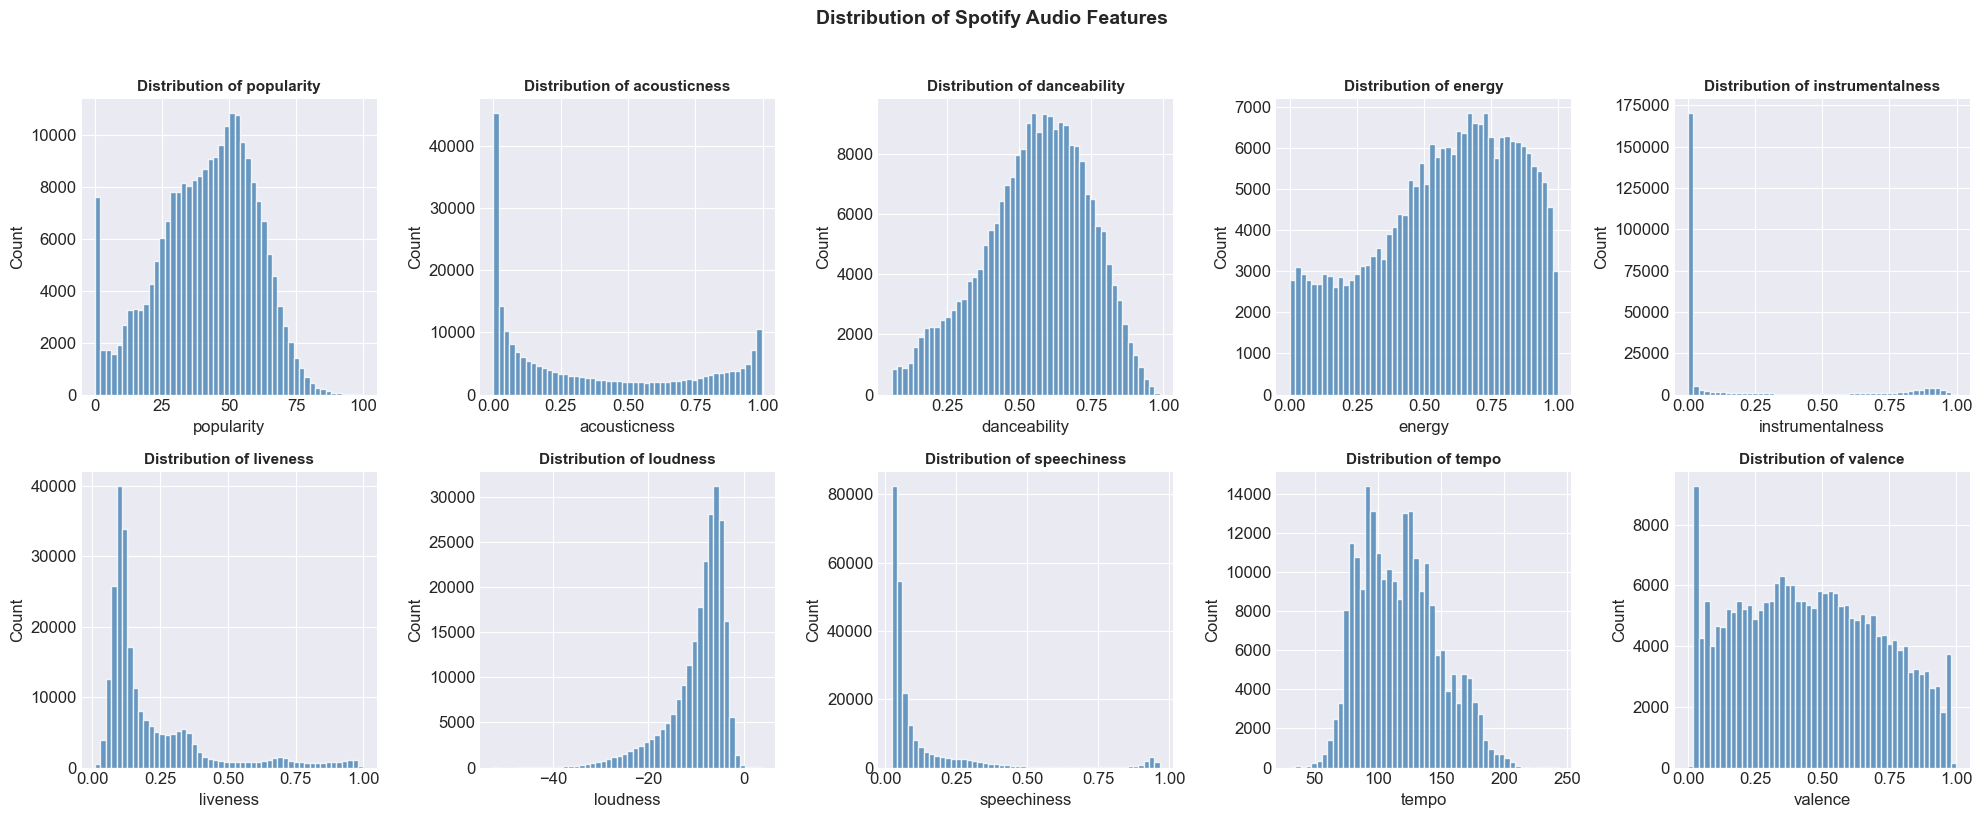

In [58]:
# Save the visualization as an image
plt.figure(figsize=(20,8))

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    axes[i].hist(df[feature].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribution of {feature}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Spotify Audio Features', fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()

# save figure
plt.savefig("spotify_features_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

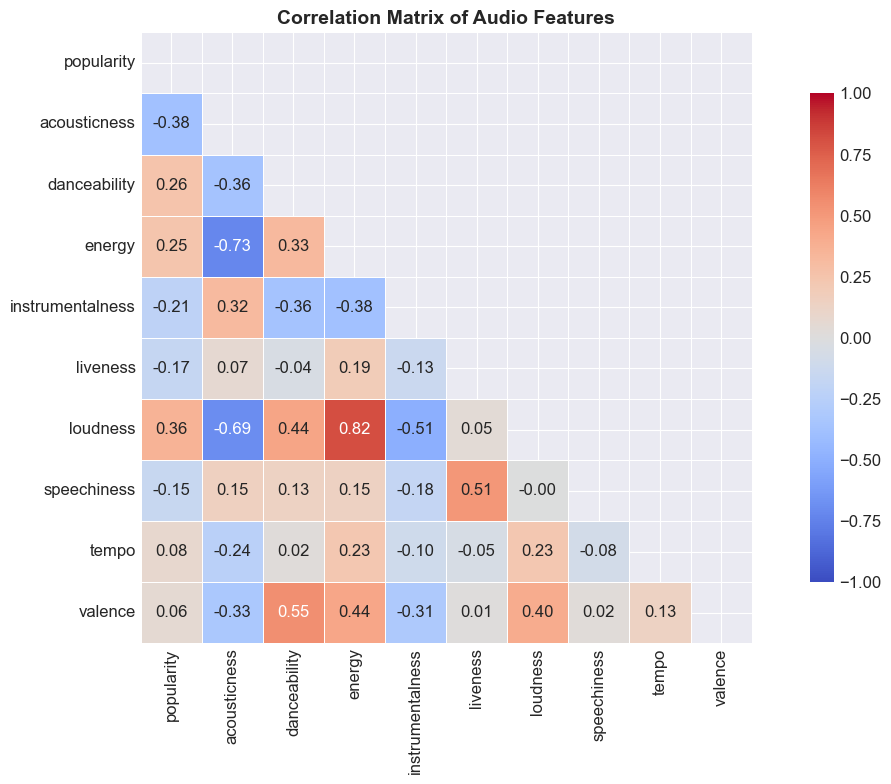

In [59]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

corr_matrix = df[numeric_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Matrix of Audio Features', fontsize=14, fontweight='bold')

plt.tight_layout()

# Save the heatmap
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

---
## 3️⃣ Data Preprocessing

In [61]:
# اختيار الـ Features للـ Clustering
clustering_features = ['danceability', 'energy', 'loudness', 'acousticness',
                       'valence', 'tempo', 'speechiness', 'liveness', 'instrumentalness']

# تنظيف الداتا
df_clean = df.dropna(subset=clustering_features).copy()
print(f' Records after cleaning: {len(df_clean):,}')

# Sample للسرعة (استخدام 30,000 صف)
SAMPLE_SIZE = 30000
df_sample = df_clean.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f' Using sample of {SAMPLE_SIZE:,} records for clustering')

X = df_sample[clustering_features].values

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'\n Data scaled. Shape: {X_scaled.shape}')

 Records after cleaning: 232,725
 Using sample of 30,000 records for clustering

 Data scaled. Shape: (30000, 9)


---
## 4️⃣ Dimensionality Reduction (PCA)

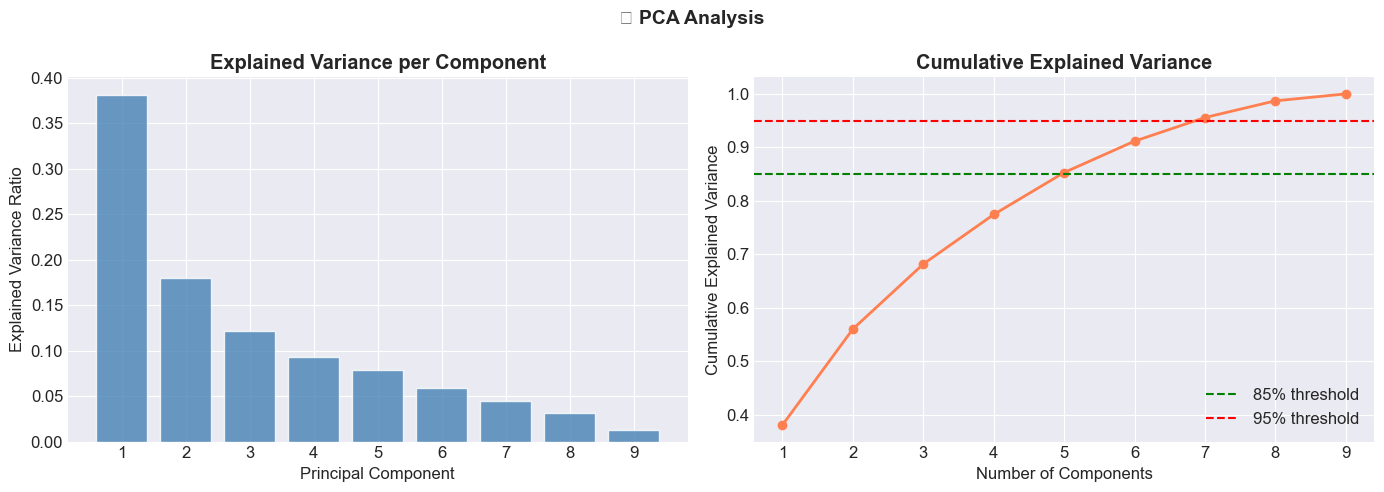

2D PCA explains: 56.1%
3D PCA explains: 68.2%


In [62]:
# PCA للتصور والتحليل
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained Variance Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Cumulative explained variance
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-', color='coral', linewidth=2)
axes[1].axhline(y=0.85, color='green', linestyle='--', label='85% threshold')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative)+1))

plt.suptitle('📊 PCA Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# PCA بـ 2 و 3 Dimensions للتصور
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f'2D PCA explains: {pca_2d.explained_variance_ratio_.sum():.1%}')
print(f'3D PCA explains: {pca_3d.explained_variance_ratio_.sum():.1%}')

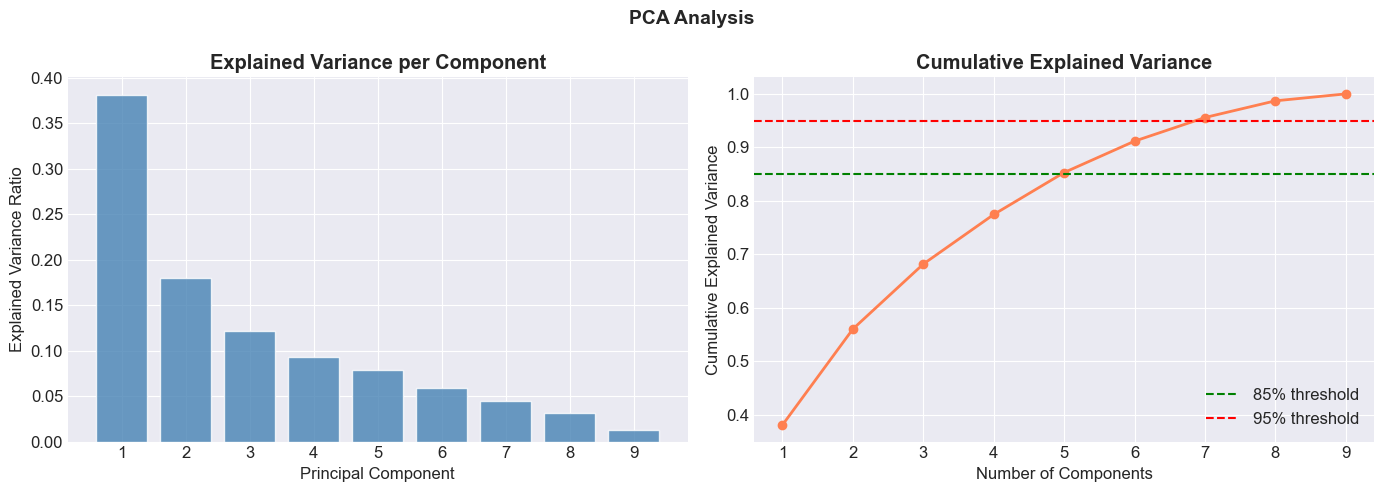

In [63]:
# PCA للتصور والتحليل
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained Variance Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Cumulative explained variance
cumulative = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative)+1), cumulative, 'o-', color='coral', linewidth=2)
axes[1].axhline(y=0.85, color='green', linestyle='--', label='85% threshold')
axes[1].axhline(y=0.95, color='red', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumulative)+1))

plt.suptitle('PCA Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save the PCA plot
plt.savefig("pca_analysis.png", dpi=300, bbox_inches='tight')

plt.show()

---
## 5️⃣ K-Means Clustering
### 5.1 Elbow Method & Silhouette Score لاختيار K

In [64]:
# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

print('Computing Elbow Method & Silhouette Scores...')
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    silhouette_scores.append(sil)
    print(f'  K={k}: Inertia={kmeans.inertia_:.0f}, Silhouette={sil:.4f}')

print(' Done!')

Computing Elbow Method & Silhouette Scores...
  K=2: Inertia=196124, Silhouette=0.3199
  K=3: Inertia=160624, Silhouette=0.3553
  K=4: Inertia=142883, Silhouette=0.2193
  K=5: Inertia=127659, Silhouette=0.1940
  K=6: Inertia=118271, Silhouette=0.2040
  K=7: Inertia=109900, Silhouette=0.2081
  K=8: Inertia=102337, Silhouette=0.1909
  K=9: Inertia=97032, Silhouette=0.1854
  K=10: Inertia=93442, Silhouette=0.1769
 Done!


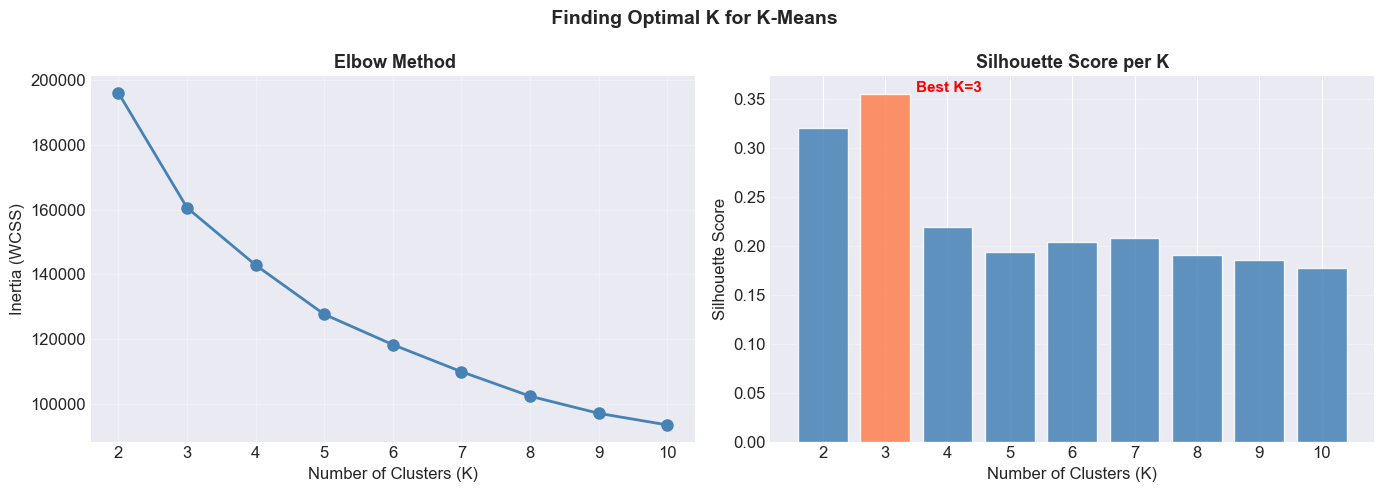


 Best K based on Silhouette Score: K = 3


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title(' Elbow Method', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

# Silhouette Scores
best_k_idx = np.argmax(silhouette_scores)
colors = ['coral' if i == best_k_idx else 'steelblue' for i in range(len(silhouette_scores))]
bars = axes[1].bar(list(K_range), silhouette_scores, color=colors, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score per K', fontsize=13, fontweight='bold')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3, axis='y')
best_k = list(K_range)[best_k_idx]
axes[1].annotate(f'Best K={best_k}', xy=(best_k, silhouette_scores[best_k_idx]),
                 xytext=(best_k+0.5, silhouette_scores[best_k_idx]+0.002),
                 fontsize=11, color='red', fontweight='bold')

plt.suptitle(' Finding Optimal K for K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n Best K based on Silhouette Score: K = {best_k}')

### 5.2 Fitting K-Means with Optimal K

In [33]:
# يمكنك تغيير K هنا بناءً على التحليل
OPTIMAL_K = best_k  # أو يدوياً مثلاً: OPTIMAL_K = 6

print(f' Training K-Means with K = {OPTIMAL_K}...')
kmeans_final = KMeans(n_clusters=OPTIMAL_K, init='k-means++', n_init=15, random_state=42)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

df_sample['KMeans_Cluster'] = kmeans_labels

# Evaluation Metrics
sil = silhouette_score(X_scaled, kmeans_labels, sample_size=5000, random_state=42)
db = davies_bouldin_score(X_scaled, kmeans_labels)
ch = calinski_harabasz_score(X_scaled, kmeans_labels)

print(f'\n K-Means Evaluation Metrics (K={OPTIMAL_K}):')
print(f'   Silhouette Score     : {sil:.4f}  (أعلى = أحسن، Max=1)')
print(f'   Davies-Bouldin Score : {db:.4f}  (أقل = أحسن، Min=0)')
print(f'   Calinski-Harabasz    : {ch:.2f} (أعلى = أحسن)')

print(f'\n Cluster Distribution:')
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f'   Cluster {cluster}: {count:,} songs ({count/len(kmeans_labels)*100:.1f}%)')

 Training K-Means with K = 3...

 K-Means Evaluation Metrics (K=3):
   Silhouette Score     : 0.3553  (أعلى = أحسن، Max=1)
   Davies-Bouldin Score : 1.0781  (أقل = أحسن، Min=0)
   Calinski-Harabasz    : 10213.22 (أعلى = أحسن)

 Cluster Distribution:
   Cluster 0: 1,313 songs (4.4%)
   Cluster 1: 21,880 songs (72.9%)
   Cluster 2: 6,807 songs (22.7%)


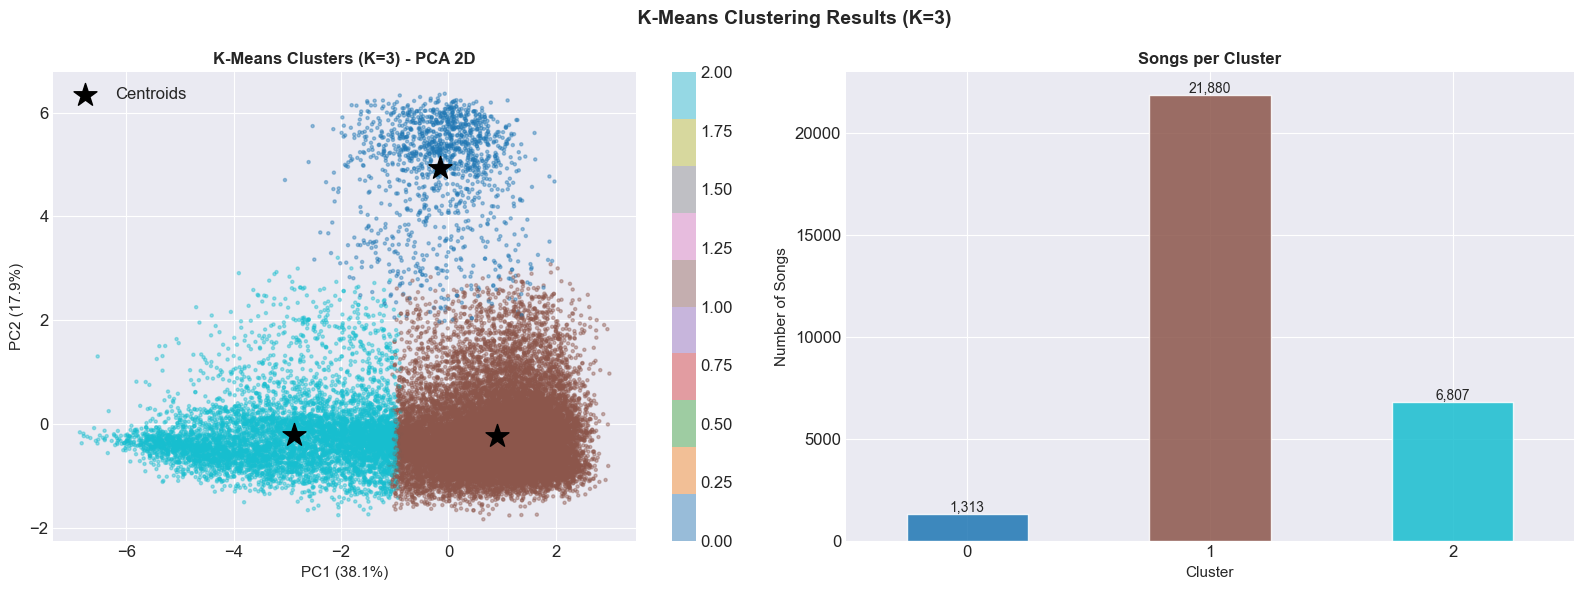

In [34]:
# Visualization with PCA 2D
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot
scatter = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                          c=kmeans_labels, cmap='tab10',
                          alpha=0.4, s=5)

# Plot Centroids
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                c='black', marker='*', s=300, zorder=5, label='Centroids')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title(f'K-Means Clusters (K={OPTIMAL_K}) - PCA 2D', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=axes[0])
axes[0].legend()

# Cluster Size Bar Chart
cluster_counts.plot(kind='bar', ax=axes[1], color=plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K)),
                    edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Number of Songs', fontsize=11)
axes[1].set_title('Songs per Cluster', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(cluster_counts):
    axes[1].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

plt.suptitle(f' K-Means Clustering Results (K={OPTIMAL_K})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [35]:
# Cluster Profiling
cluster_profiles = df_sample.groupby('KMeans_Cluster')[clustering_features].mean()
print('Cluster Profiles (Mean Feature Values):')
display(cluster_profiles.round(3))

Cluster Profiles (Mean Feature Values):


,danceability,energy,loudness,acousticness,valence,tempo,speechiness,liveness,instrumentalness
KMeans_Cluster,,,,,,,,,
0,0.558,0.665,-11.898,0.777,0.408,97.916,0.867,0.726,0.001
1,0.612,0.679,-6.949,0.201,0.533,122.354,0.097,0.197,0.068
2,0.369,0.214,-17.430,0.822,0.218,105.854,0.051,0.163,0.438


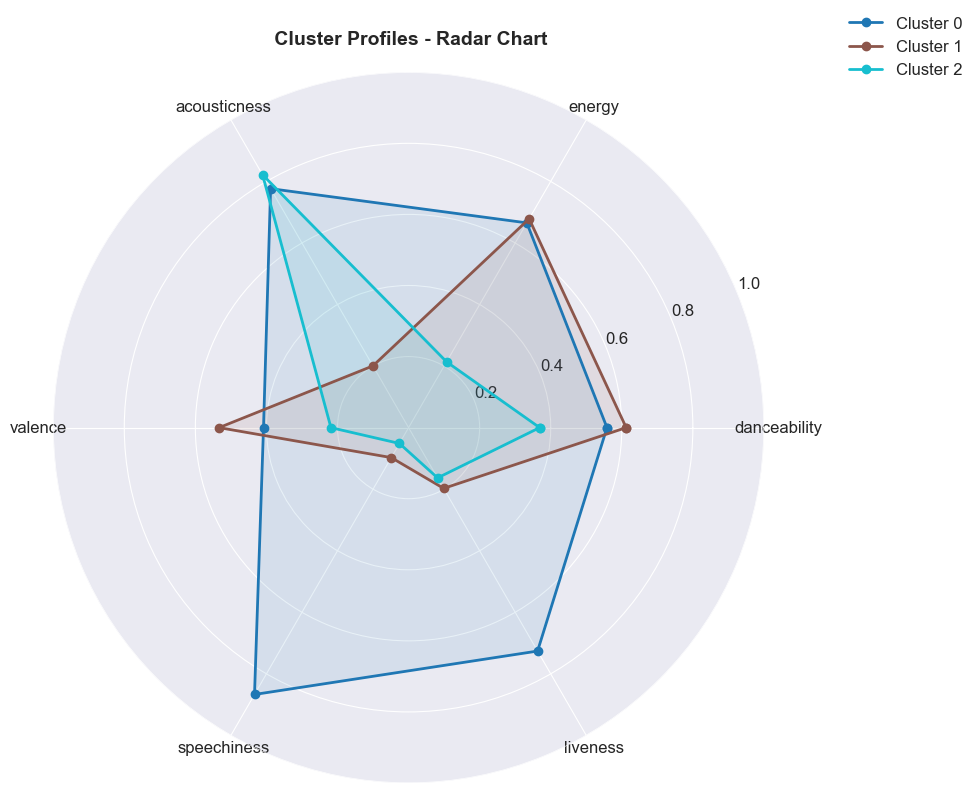

In [36]:
# Radar Chart للـ Cluster Profiles
features_radar = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'liveness']
cluster_means = df_sample.groupby('KMeans_Cluster')[features_radar].mean()

N = len(features_radar)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the loop

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))

for i, (cluster_id, row) in enumerate(cluster_means.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}', color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(features_radar, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title(' Cluster Profiles - Radar Chart', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

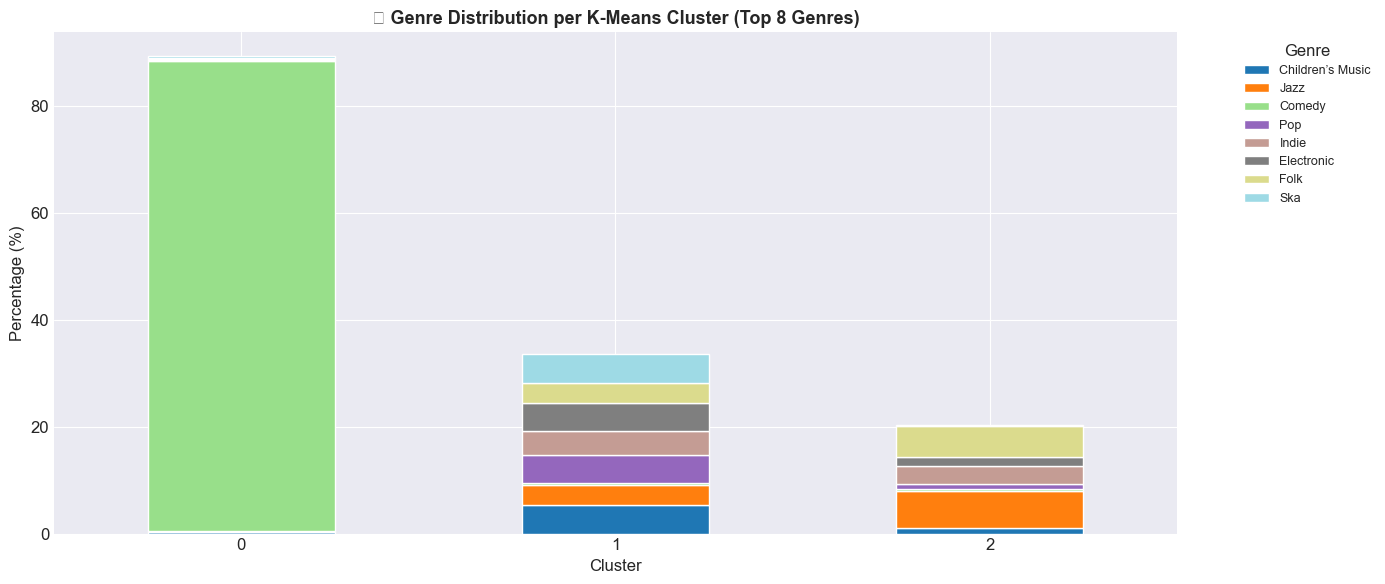

In [37]:
# Genre Distribution per Cluster
genre_cluster = df_sample.groupby(['KMeans_Cluster', 'genre']).size().unstack(fill_value=0)

# Normalize to percentages
genre_cluster_pct = genre_cluster.div(genre_cluster.sum(axis=1), axis=0) * 100

# Top 8 genres
top_genres = df_sample['genre'].value_counts().head(8).index
genre_cluster_pct_top = genre_cluster_pct[top_genres]

plt.figure(figsize=(14, 6))
genre_cluster_pct_top.plot(kind='bar', stacked=True, colormap='tab20', edgecolor='white', ax=plt.gca())
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('🎵 Genre Distribution per K-Means Cluster (Top 8 Genres)', fontsize=13, fontweight='bold')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

---
## 6️⃣ Hierarchical Clustering

 Computing Dendrogram on 500 samples...


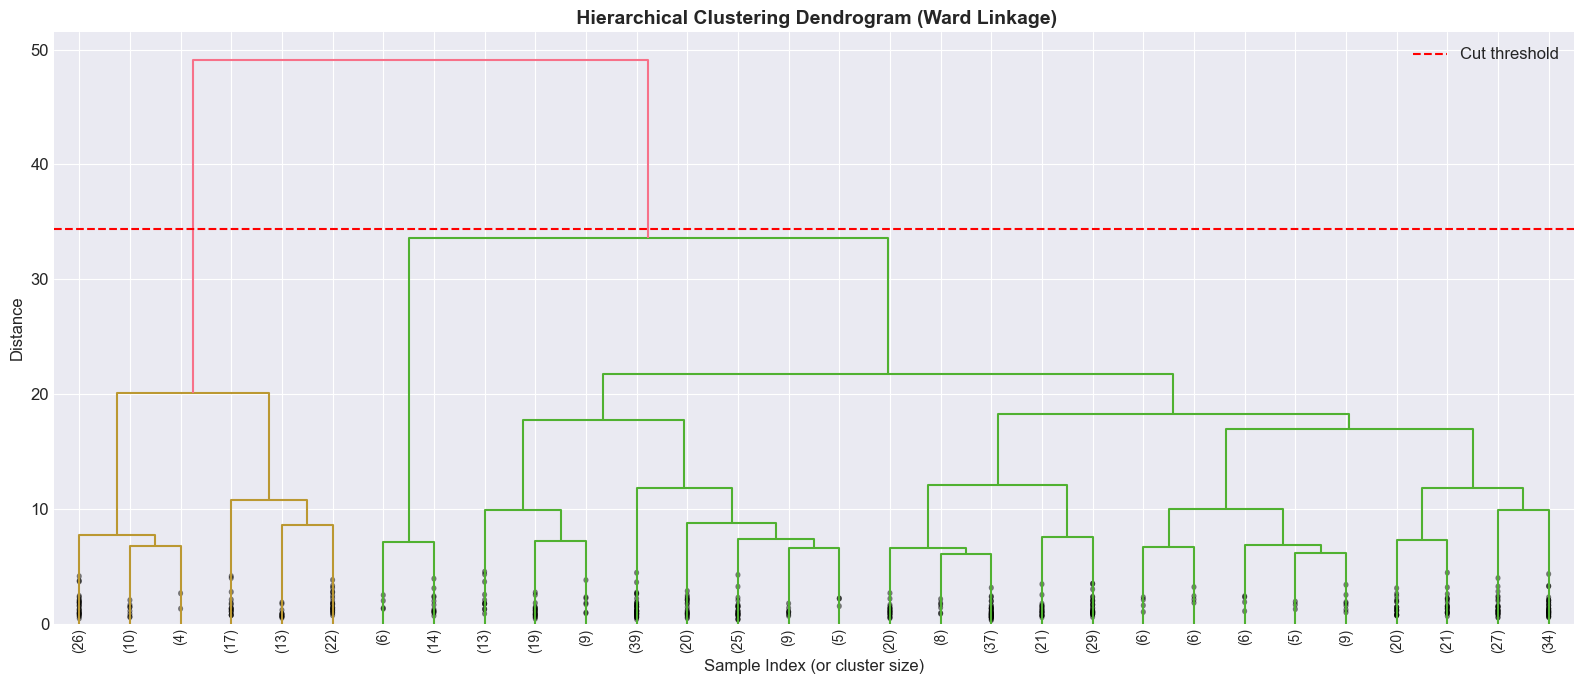

 Done!


In [38]:
# Dendrogram على sample صغير للتصور
sample_size_dendro = 500
X_dendro = X_scaled[:sample_size_dendro]

print(f' Computing Dendrogram on {sample_size_dendro} samples...')
linkage_matrix = linkage(X_dendro, method='ward', metric='euclidean')

plt.figure(figsize=(16, 7))
dendrogram(linkage_matrix,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True,
           color_threshold=0.7*max(linkage_matrix[:, 2]))

plt.title(' Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index (or cluster size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=0.7*max(linkage_matrix[:, 2]), color='r', linestyle='--', label='Cut threshold')
plt.legend()
plt.tight_layout()
plt.show()
print(' Done!')

 Fitting Agglomerative Clustering with K=3...

 Hierarchical Clustering Metrics (K=3):
   Silhouette Score     : 0.2680
   Davies-Bouldin Score : 1.2843
   Calinski-Harabasz    : 8130.19


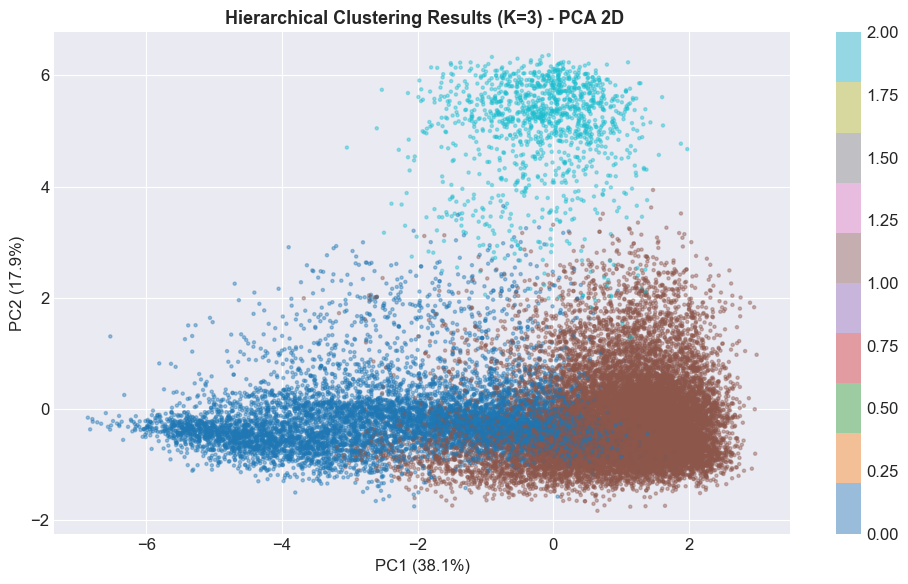

In [39]:
# Agglomerative Clustering
print(f' Fitting Agglomerative Clustering with K={OPTIMAL_K}...')

agglo = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agglo_labels = agglo.fit_predict(X_scaled)

df_sample['Hierarchical_Cluster'] = agglo_labels

# Evaluation
sil_h = silhouette_score(X_scaled, agglo_labels, sample_size=5000, random_state=42)
db_h = davies_bouldin_score(X_scaled, agglo_labels)
ch_h = calinski_harabasz_score(X_scaled, agglo_labels)

print(f'\n Hierarchical Clustering Metrics (K={OPTIMAL_K}):')
print(f'   Silhouette Score     : {sil_h:.4f}')
print(f'   Davies-Bouldin Score : {db_h:.4f}')
print(f'   Calinski-Harabasz    : {ch_h:.2f}')

# Visualization
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=agglo_labels, cmap='tab10',
                      alpha=0.4, s=5)
plt.colorbar(scatter)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
plt.title(f' Hierarchical Clustering Results (K={OPTIMAL_K}) - PCA 2D',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7️⃣ DBSCAN Clustering

 Finding optimal epsilon using k-distance graph...


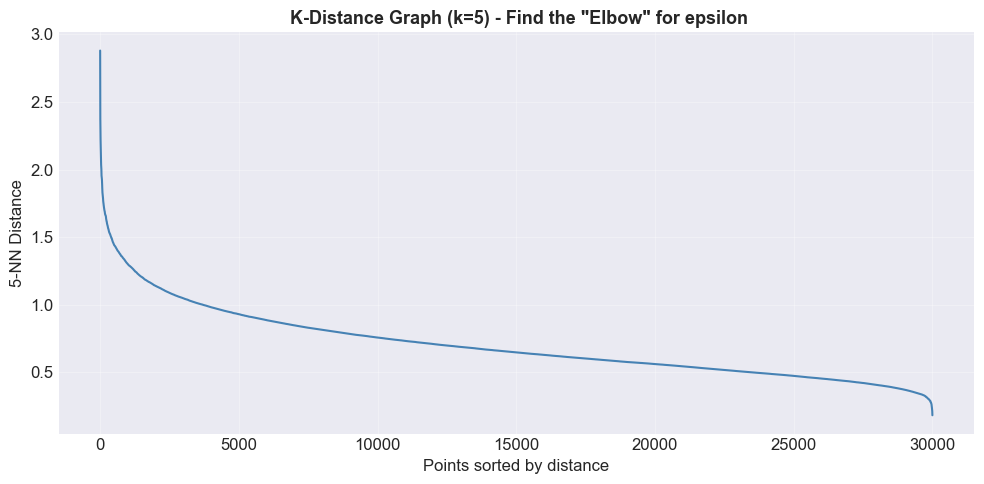

 Look at the plot and find the "elbow" point - that's your optimal epsilon


In [40]:
# إيجاد الـ Optimal Epsilon
print(' Finding optimal epsilon using k-distance graph...')

k_neighbors = 5
nbrs = NearestNeighbors(n_neighbors=k_neighbors).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, k_neighbors-1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, color='steelblue', linewidth=1.5)
plt.xlabel('Points sorted by distance', fontsize=12)
plt.ylabel(f'{k_neighbors}-NN Distance', fontsize=12)
plt.title(f' K-Distance Graph (k={k_neighbors}) - Find the "Elbow" for epsilon',
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(' Look at the plot and find the "elbow" point - that\'s your optimal epsilon')

In [42]:
# DBSCAN Parameters - عدّلهم بناءً على الـ K-Distance Graph
EPS = 1.5      # يمكن تعديله
MIN_SAMPLES = 10  # يمكن تعديله

print(f' Running DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES})...')

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, metric='euclidean', n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_scaled)

df_sample['DBSCAN_Cluster'] = dbscan_labels

# Results
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = np.sum(dbscan_labels == -1)
n_total = len(dbscan_labels)

print(f'\n DBSCAN Results:')
print(f'   Clusters found   : {n_clusters_db}')
print(f'   Noise points     : {n_noise:,} ({n_noise/n_total*100:.1f}%)')
print(f'   Clustered points : {n_total - n_noise:,} ({(n_total - n_noise)/n_total*100:.1f}%)')

if n_clusters_db > 1:
    non_noise_mask = dbscan_labels != -1
    sil_db = silhouette_score(X_scaled[non_noise_mask], dbscan_labels[non_noise_mask],
                               sample_size=min(5000, non_noise_mask.sum()), random_state=42)
    print(f'   Silhouette Score : {sil_db:.4f}')
else:
    print(' Less than 2 clusters found. Try adjusting eps and min_samples.')

 Running DBSCAN (eps=1.5, min_samples=10)...

 DBSCAN Results:
   Clusters found   : 1
   Noise points     : 225 (0.8%)
   Clustered points : 29,775 (99.2%)
 Less than 2 clusters found. Try adjusting eps and min_samples.


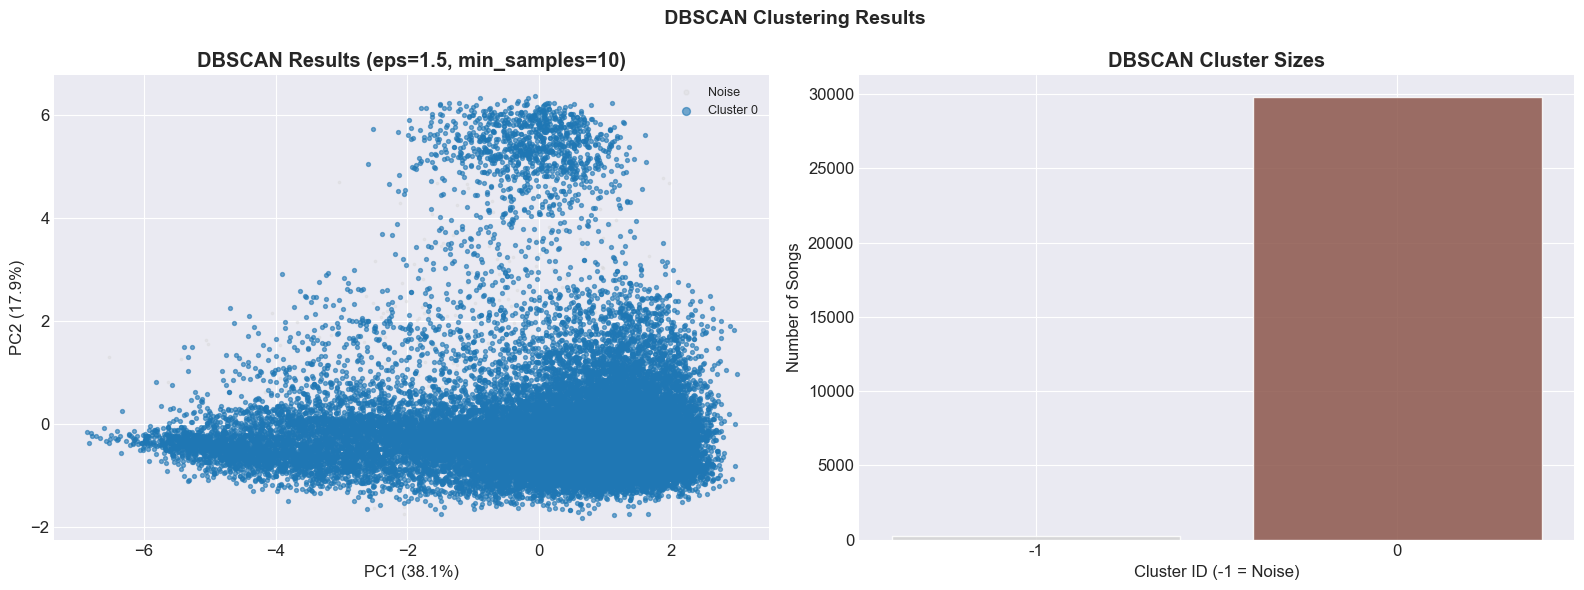

In [43]:
# DBSCAN Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All points
unique_labels = set(dbscan_labels)
colors_db = plt.cm.tab10(np.linspace(0, 1, max(n_clusters_db, 1)))

for k, col in zip(sorted(unique_labels), ['black'] + list(colors_db)):
    if k == -1:
        color = 'lightgray'
        label_name = 'Noise'
        alpha = 0.3
        size = 3
    else:
        color = plt.cm.tab10(k / max(n_clusters_db, 1))
        label_name = f'Cluster {k}'
        alpha = 0.6
        size = 8
    
    mask = dbscan_labels == k
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   c=[color], alpha=alpha, s=size, label=label_name if k < 8 else None)

axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
axes[0].set_title(f'DBSCAN Results (eps={EPS}, min_samples={MIN_SAMPLES})', fontweight='bold')
axes[0].legend(markerscale=2, fontsize=9)

# Cluster distribution
cluster_dist = pd.Series(dbscan_labels).value_counts().sort_index()
bar_colors = ['lightgray' if idx == -1 else plt.cm.tab10(i/(len(cluster_dist))) 
              for i, idx in enumerate(cluster_dist.index)]
bars = axes[1].bar([str(i) for i in cluster_dist.index], cluster_dist.values,
                   color=bar_colors, edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Cluster ID (-1 = Noise)')
axes[1].set_ylabel('Number of Songs')
axes[1].set_title('DBSCAN Cluster Sizes', fontweight='bold')

plt.suptitle(' DBSCAN Clustering Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8️⃣ Model Comparison

In [44]:
# مقارنة الـ Models
comparison_data = {
    'Algorithm': ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'Clusters Found': [OPTIMAL_K, OPTIMAL_K, n_clusters_db],
    'Silhouette Score': [sil, sil_h, sil_db if n_clusters_db > 1 else 'N/A'],
    'Davies-Bouldin': [db, db_h, 'N/A'],
    'Calinski-Harabasz': [round(ch, 1), round(ch_h, 1), 'N/A'],
    'Noise Points': [0, 0, n_noise]
}

comparison_df = pd.DataFrame(comparison_data)
print('📊 Model Comparison Summary:')
display(comparison_df)

print('\n Notes:')
print('   - Silhouette Score: أعلى = أحسن (range: -1 to 1)')
print('   - Davies-Bouldin  : أقل = أحسن (Min=0)')
print('   - Calinski-Harabasz: أعلى = أحسن')

📊 Model Comparison Summary:


,Algorithm,Clusters Found,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise Points
0,K-Means,3,0.355326,1.078128,10213.2,0
1,Hierarchical (Ward),3,0.267996,1.284322,8130.2,0
2,DBSCAN,1,N/A,N/A,N/A,225



 Notes:
   - Silhouette Score: أعلى = أحسن (range: -1 to 1)
   - Davies-Bouldin  : أقل = أحسن (Min=0)
   - Calinski-Harabasz: أعلى = أحسن


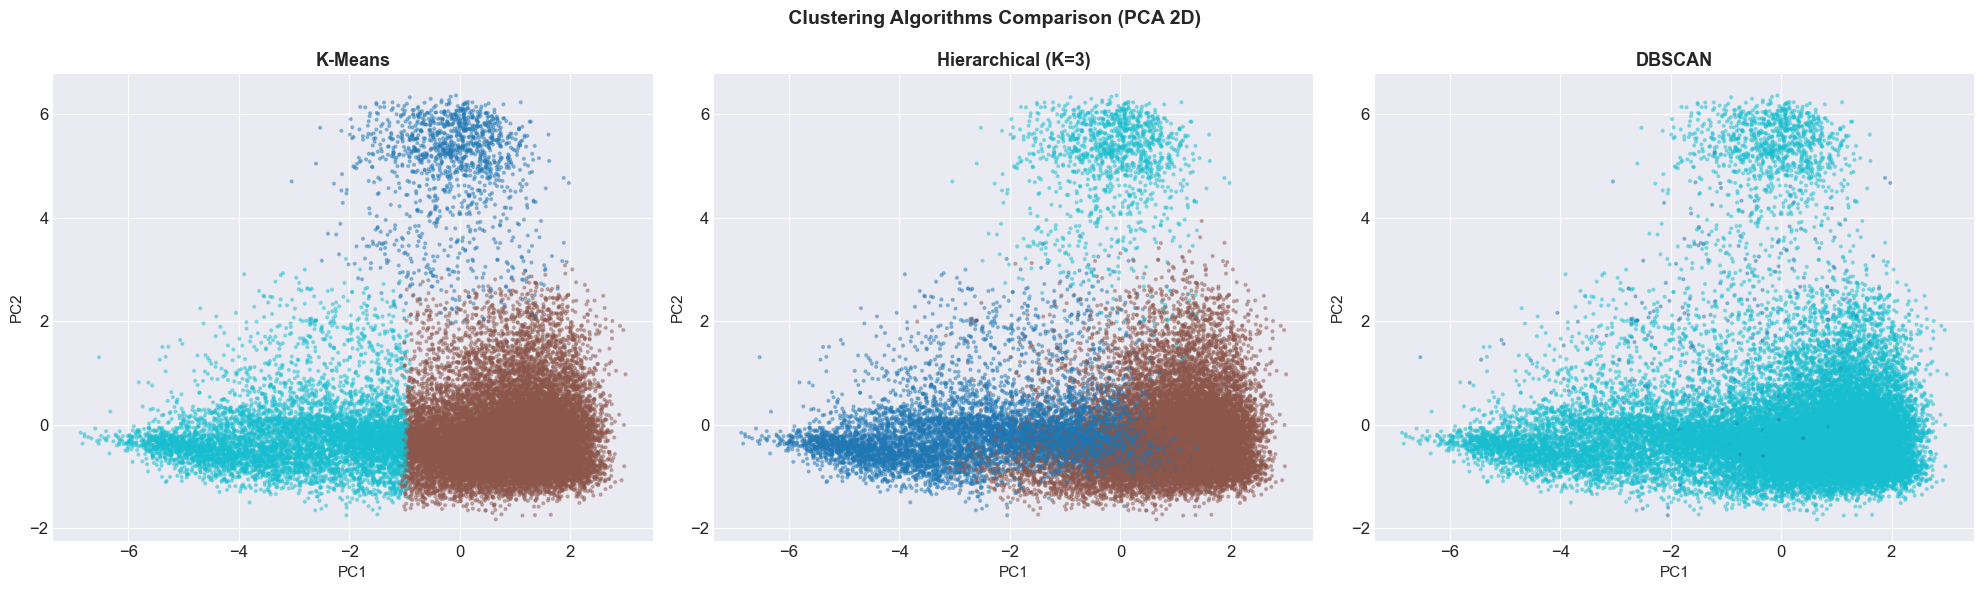

In [45]:
# Visual Comparison Side by Side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, labels, title in zip(
    axes,
    [kmeans_labels, agglo_labels, dbscan_labels],
    ['K-Means', f'Hierarchical (K={OPTIMAL_K})', f'DBSCAN']
):
    scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                        c=labels, cmap='tab10',
                        alpha=0.4, s=4)
    ax.set_xlabel('PC1', fontsize=11)
    ax.set_ylabel('PC2', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle(' Clustering Algorithms Comparison (PCA 2D)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Cluster Insights & Song Recommendations

In [47]:
# أمثلة أغانى من كل Cluster
print('Sample Songs from Each K-Means Cluster:\n')
for cluster_id in sorted(df_sample['KMeans_Cluster'].unique()):
    cluster_songs = df_sample[df_sample['KMeans_Cluster'] == cluster_id]
    
    # أهم خصائص الـ Cluster
    mean_dance = cluster_songs['danceability'].mean()
    mean_energy = cluster_songs['energy'].mean()
    mean_valence = cluster_songs['valence'].mean()
    mean_acoustic = cluster_songs['acousticness'].mean()
    
    # وصف الـ Cluster
    vibe = []
    if mean_dance > 0.6: vibe.append(' Danceable')
    if mean_energy > 0.6: vibe.append(' High Energy')
    elif mean_energy < 0.3: vibe.append(' Calm')
    if mean_valence > 0.6: vibe.append('Happy/Positive')
    elif mean_valence < 0.3: vibe.append('Sad/Melancholic')
    if mean_acoustic > 0.6: vibe.append(' Acoustic')
    
    print(f'━━━ Cluster {cluster_id} ({" | ".join(vibe) if vibe else "Mixed"}): {len(cluster_songs):,} songs')
    print(f'    Dance={mean_dance:.2f}, Energy={mean_energy:.2f}, Valence={mean_valence:.2f}, Acoustic={mean_acoustic:.2f}')
    
    # Top genres
    top_genre = cluster_songs['genre'].value_counts().head(3).index.tolist()
    print(f'    Top Genres: {" | ".join(top_genre)}')
    
    # Sample songs
    sample_songs = cluster_songs.nlargest(3, 'popularity')[['track_name', 'artist_name', 'popularity']]
    for _, song in sample_songs.iterrows():
        print(f'     "{song["track_name"]}" - {song["artist_name"]} (popularity: {song["popularity"]})')
    print()

Sample Songs from Each K-Means Cluster:

━━━ Cluster 0 ( High Energy |  Acoustic): 1,313 songs
    Dance=0.56, Energy=0.67, Valence=0.41, Acoustic=0.78
    Top Genres: Comedy | Movie | Rap
     "Carrollton" - $uicideBoy$ (popularity: 72)
     "out for the night - part 2" - 21 Savage (popularity: 72)
     "Muerte En Hawaii" - Calle 13 (popularity: 72)

━━━ Cluster 1 ( Danceable |  High Energy): 21,880 songs
    Dance=0.61, Energy=0.68, Valence=0.53, Acoustic=0.20
    Top Genres: Ska | Children’s Music | Rap
     "Sunflower - Spider-Man: Into the Spider-Verse" - Post Malone (popularity: 97)
     "Calma - Remix" - Pedro Capó (popularity: 97)
     "ZEZE (feat. Travis Scott & Offset)" - Kodak Black (popularity: 93)

━━━ Cluster 2 ( Calm | Sad/Melancholic |  Acoustic): 6,807 songs
    Dance=0.37, Energy=0.21, Valence=0.22, Acoustic=0.82
    Top Genres: Soundtrack | Classical | Opera
     "All of Me" - John Legend (popularity: 85)
     "Best Part (feat. Daniel Caesar)" - H.E.R. (popularity: 8

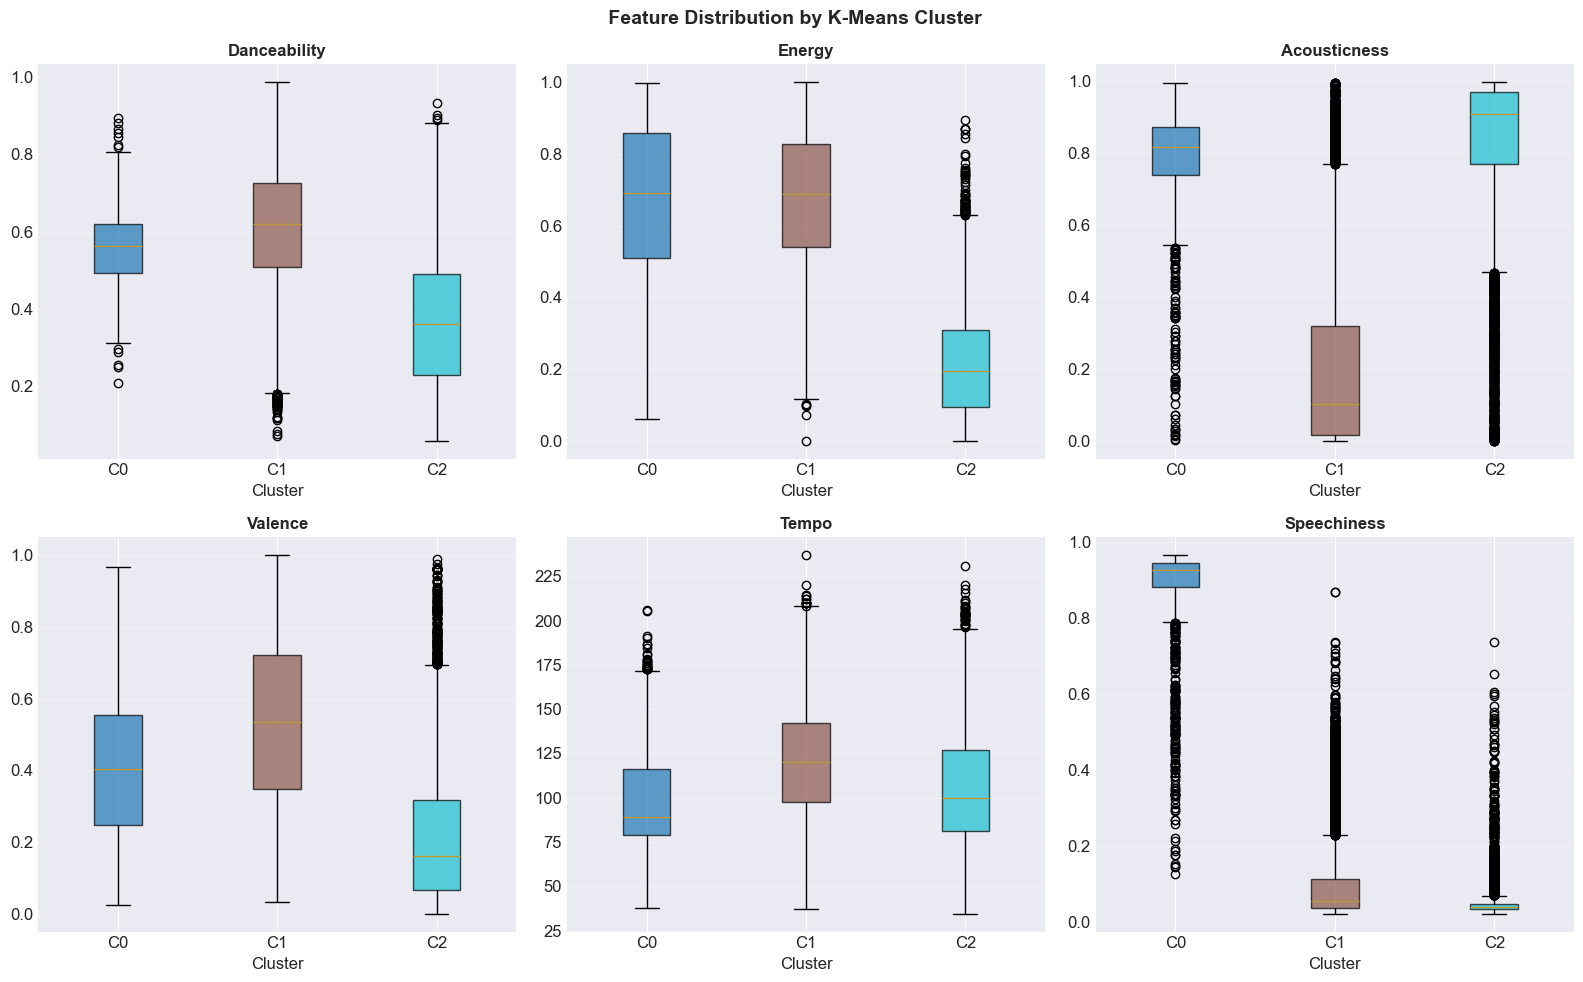

In [48]:
# BoxPlots للـ Features عبر الـ Clusters
features_to_plot = ['danceability', 'energy', 'acousticness', 'valence', 'tempo', 'speechiness']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    data_grouped = [df_sample[df_sample['KMeans_Cluster'] == c][feature].values
                    for c in sorted(df_sample['KMeans_Cluster'].unique())]
    
    bp = axes[i].boxplot(data_grouped, patch_artist=True,
                         labels=[f'C{c}' for c in sorted(df_sample['KMeans_Cluster'].unique())])
    
    colors_bp = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[i].set_title(f'{feature.capitalize()}', fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Cluster')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.suptitle(' Feature Distribution by K-Means Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔟 Save Results

In [49]:
# حفظ النتائج
output_cols = ['track_name', 'artist_name', 'genre', 'popularity'] + \
              clustering_features + \
              ['KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']

results_df = df_sample[output_cols]
results_df.to_csv('SpotifyFeatures_Clustered.csv', index=False)

print(' Results saved to: SpotifyFeatures_Clustered.csv')
print(f'   Total records: {len(results_df):,}')
print(f'   Columns: {results_df.columns.tolist()}')
results_df.head()

 Results saved to: SpotifyFeatures_Clustered.csv
   Total records: 30,000
   Columns: ['track_name', 'artist_name', 'genre', 'popularity', 'danceability', 'energy', 'loudness', 'acousticness', 'valence', 'tempo', 'speechiness', 'liveness', 'instrumentalness', 'KMeans_Cluster', 'Hierarchical_Cluster', 'DBSCAN_Cluster']


,track_name,artist_name,genre,popularity,danceability,energy,loudness,acousticness,valence,tempo,speechiness,liveness,instrumentalness,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,My Time's Comin',A Thousand Horses,Country,45,0.327,0.8350,-4.952,0.00192,0.3850,171.795,0.0609,0.1670,0.000150,1,1,0
1,House Tour,Mark Mothersbaugh,Soundtrack,25,0.253,0.0798,-18.512,0.93200,0.0487,110.931,0.0439,0.0906,0.568000,2,0,0
2,We Can't Fall (Remix) [feat. J. Patz],Unified Highway,Reggae,19,0.821,0.7370,-6.295,0.03310,0.7870,137.968,0.2120,0.1320,0.013400,1,1,0
3,Endz - Original Mix,Stooki Sound,Electronic,29,0.745,0.7720,-3.949,0.00428,0.1700,133.113,0.0904,0.0722,0.114000,1,1,0
4,I Love My Job (Live),Bill Hicks,Comedy,17,0.502,0.8040,-9.935,0.96500,0.1850,104.576,0.8070,0.9020,0.000096,0,2,0


---
##  Summary

### ما عملناه في الـ Notebook ده:

| Step | Description |
|------|-------------|
| 1️⃣ | Load & Explore Data (232K+ songs) |
| 2️⃣ | Preprocessing & Standard Scaling |
| 3️⃣ | PCA for Dimensionality Reduction |
| 4️⃣ | K-Means: Elbow + Silhouette to find optimal K |
| 5️⃣ | Hierarchical Clustering (Ward Linkage) |
| 6️⃣ | DBSCAN (density-based clustering) |
| 7️⃣ | Model Comparison |
| 8️⃣ | Cluster Profiling & Insights |

### الـ Features المستخدمة:
`danceability, energy, loudness, acousticness, valence, tempo, speechiness, liveness, instrumentalness`

### النتائج:
- كل Cluster يمثل "نوع صوت" مختلف للأغانى (energetic, chill, acoustic, danceable...)
- يمكن استخدام النتائج لبناء نظام توصيات موسيقية